# Task 3 · Step 3 — Canonical GRPO vs Dr. GRPO normalisation

**Objective.** For a prompt with $K$ sampled completions and rewards $r_1..r_K$, $A_k=(r_k-\mu_r)/(\sigma_r+\varepsilon)$ with $\mu_r,\sigma_r$ computed **within the prompt's group**, and
$$\mathcal{L}_{\text{GRPO}}=-\mathbb{E}_k\Big[\tfrac{1}{T_k}\sum_{t=1}^{T_k}\min\big(\rho_{k,t}A_k,\ \text{clip}(\rho_{k,t},1-\epsilon,1+\epsilon)A_k\big)\Big]+\beta\,D_{\text{KL}}(\pi_\theta\|\pi_{\text{ref}})$$
(k3 KL estimator). Dr. GRPO replaces $1/T_k$ by the constant $1/L_{\max}$.

**Setting.** Continuation from the supplied GRPO midpoint adapter, the same reward model and prompt pool as PPO, K = 4 completions per prompt, 1 prompt per update (pool indices 0, 1, 2, …), 1 policy epoch, lr 5e-6, ε = 0.20, β = 0.10, cap 512 tokens; completions that hit the cap are masked out of the loss (their reward still enters the group statistics). Held-out evaluation: 64 fixed prompts, T = 0.7, top-p 0.9, cap 512, same seed for every condition. LoRA dropout is disabled during updates.

**Protocol.** Two matched 8-update forks from the identical midpoint (same prompts, reward, β, ε, generation settings and budget); only the sequence normalisation changes. During training every completion is forwarded and back-propagated on its own (the batch loss decomposes exactly over completions), and the L2 norm of its gradient contribution is logged next to its length and advantage.

**Length-conditioned statistic (defined once).** Spearman correlation between completion length $T_k$ and gradient norm per unit advantage $\|g_k\|/|A_k|$, plus the share of total gradient mass carried by the shortest and longest third of trained completions.

**Research question (RQ2).** Does the normalisation change response length or the allocation of gradient magnitude across short and long completions? Are those changes associated with quality?


In [1]:
%matplotlib inline
import os, sys, json, re
from pathlib import Path
ROOT = Path.cwd()
while not (ROOT / "configs").exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
os.chdir(ROOT); sys.path.insert(0, str(ROOT))
import numpy as np, pandas as pd, matplotlib.pyplot as plt, yaml
from IPython.display import display, Markdown, HTML, Image
from common.nb_helpers import (style, load, jl, exists, pending, run, side_by_side, ci_text,
                               bootstrap_mean_diff, smooth, full_windows, PALETTE, SEQ, RES, FIG)
from common.metrics import length_stats, wilson_interval
from common.data import load_yaml
style()
print("repo root:", ROOT)

repo root: C:\Users\moize\OneDrive - Higher Education Commission\Desktop\Academics\ATML\PA2


## Run this step (optional)
The results below come from the Kaggle run of the script pipeline (`kaggle_runner.ipynb`). Set `FORCE_RUN = True`
to re-run the step's scripts from here (needs a CUDA GPU and the downloaded course assets).


In [2]:
FORCE_RUN = False
if FORCE_RUN:
    run('python -m task3_grpo.compare_normalization --config configs/grpo.yaml --skip-train')
else:
    print('Using saved results under results/ (FORCE_RUN = False).')

Using saved results under results/ (FORCE_RUN = False).


## 1. What the two normalisations do to per-token and per-sequence weight

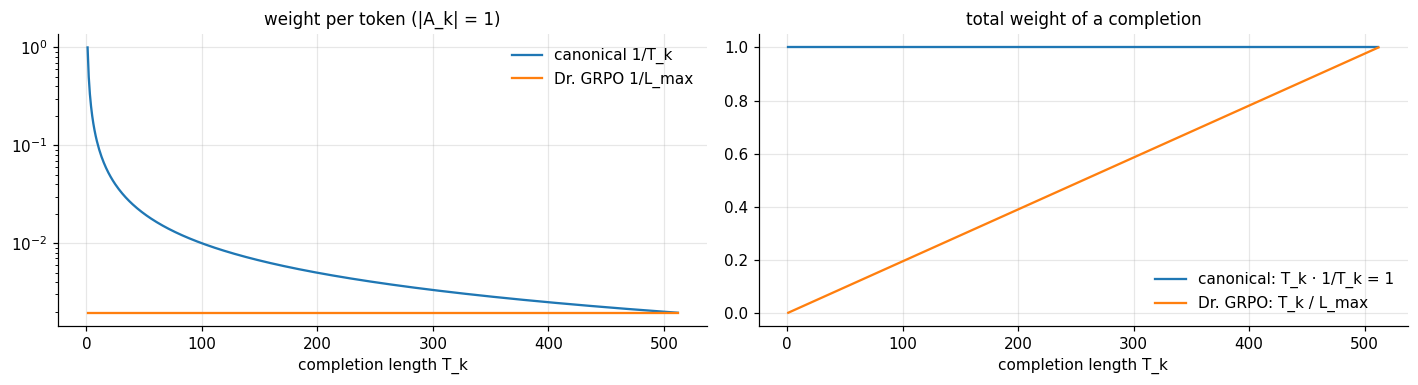

In [3]:
T = np.arange(1, 513); Lmax = 512
fig, ax = plt.subplots(1, 2, figsize=(13, 3.6))
ax[0].plot(T, 1 / T, label="canonical 1/T_k"); ax[0].plot(T, np.full_like(T, 1 / Lmax, dtype=float), label="Dr. GRPO 1/L_max")
ax[0].set_yscale("log"); ax[0].set_xlabel("completion length T_k"); ax[0].set_title("weight per token (|A_k| = 1)"); ax[0].legend()
ax[1].plot(T, np.ones_like(T, dtype=float), label="canonical: T_k · 1/T_k = 1"); ax[1].plot(T, T / Lmax, label="Dr. GRPO: T_k / L_max")
ax[1].set_xlabel("completion length T_k"); ax[1].set_title("total weight of a completion"); ax[1].legend(); fig.tight_layout(); plt.show()

## 2. Training trajectories of the two forks

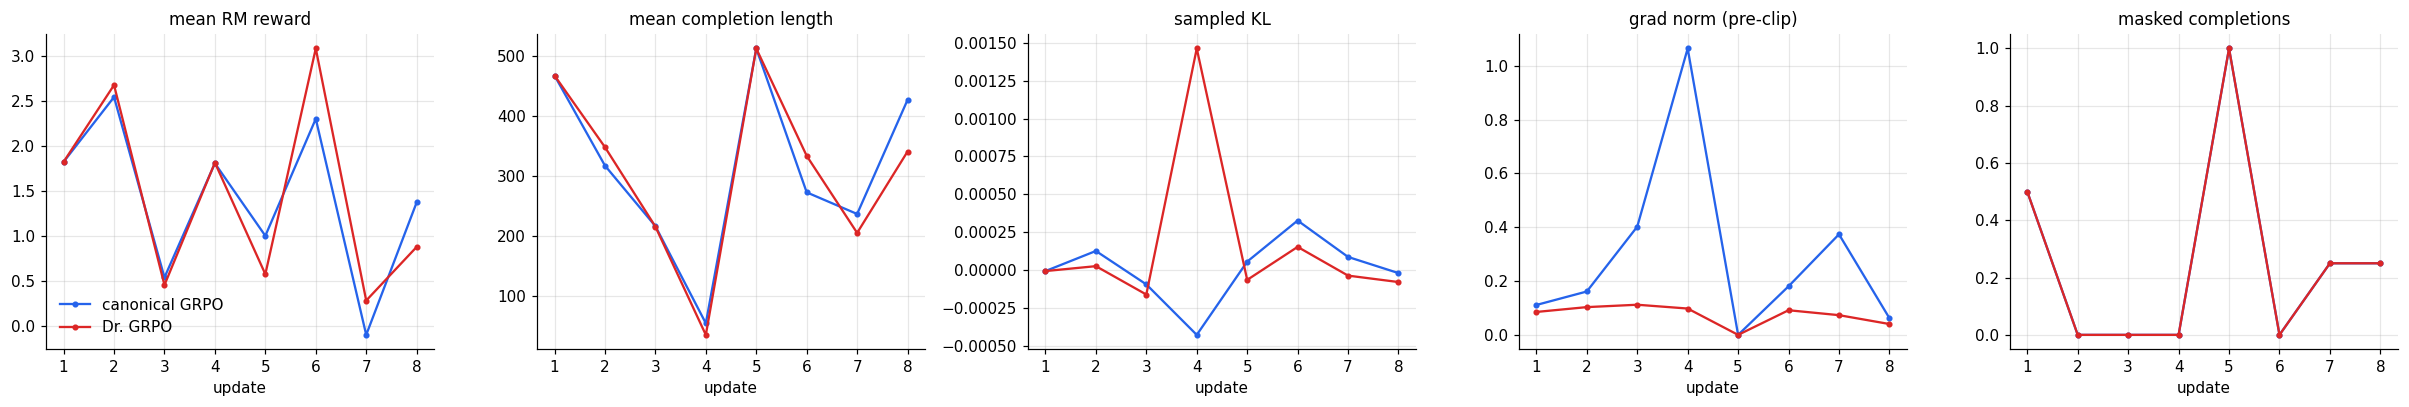

In [4]:
LT = {"canonical GRPO": pd.DataFrame(jl("task3_grpo/grpo_train_fork_norm_grpo.jsonl")), "Dr. GRPO": pd.DataFrame(jl("task3_grpo/grpo_train_fork_norm_dr_grpo.jsonl"))}
fig, ax = plt.subplots(1, 5, figsize=(22, 3.8))
for (n, Lf), c in zip(LT.items(), ["#2563EB", "#DC2626"]):
    for a, k in zip(ax, ["reward_mean", "response_length", "kl_token_mean", "grad_norm", "masked_fraction"]):
        a.plot(Lf["update"], Lf[k], "o-", ms=3, color=c, label=n)
for a, t in zip(ax, ["mean RM reward", "mean completion length", "sampled KL", "grad norm (pre-clip)", "masked completions"]):
    a.set_title(t); a.set_xlabel("update")
ax[0].legend(); fig.tight_layout(); plt.show()

## 3. Per-completion gradient vs length

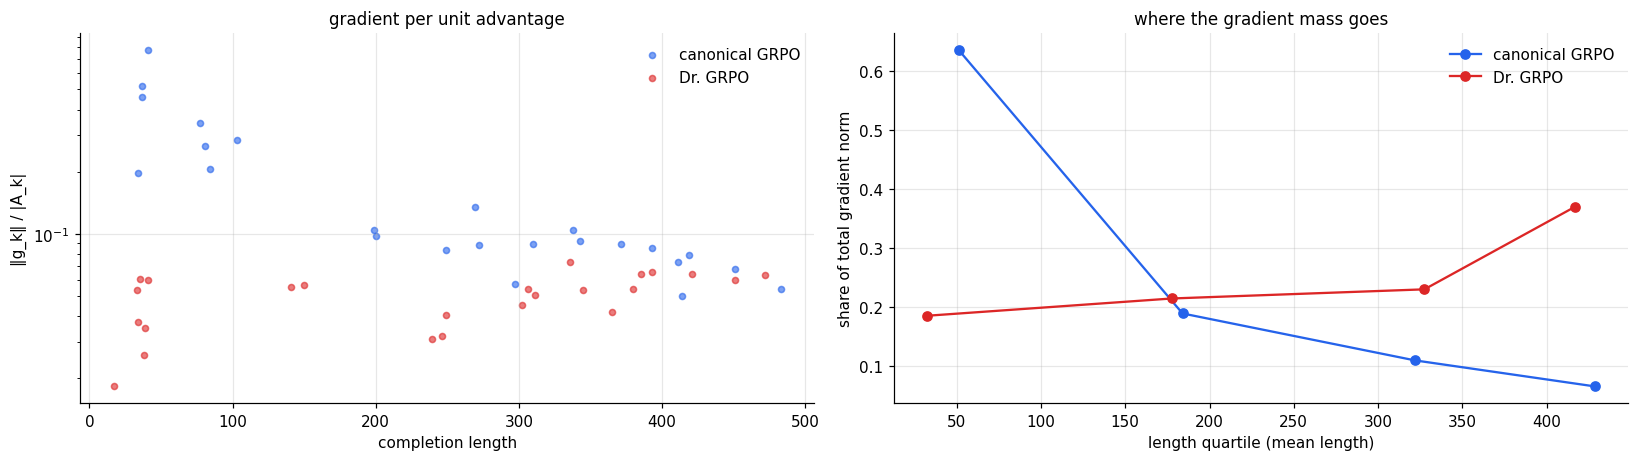

,canonical GRPO (1/T_k),Dr. GRPO (1/L_max)
trained_completions,24.0000,24.0000
masked_completions,8.0000,8.0000
spearman_length_vs_gradnorm,-0.8261,0.2496
spearman_length_vs_gradnorm_per_unit_adv,-0.8774,0.5748
grad_mass_share_shortest_third,0.7311,0.3069
grad_mass_share_longest_third,0.0910,0.4349
mean_gradnorm_short_third,0.3777,0.0388
mean_gradnorm_long_third,0.0470,0.0550


In [5]:
RC = {"canonical GRPO": pd.DataFrame(jl("task3_grpo/grpo_rollouts_fork_norm_grpo.jsonl")), "Dr. GRPO": pd.DataFrame(jl("task3_grpo/grpo_rollouts_fork_norm_dr_grpo.jsonl"))}
fig, ax = plt.subplots(1, 2, figsize=(15, 4.3))
for (n, r), c in zip(RC.items(), ["#2563EB", "#DC2626"]):
    t = r[~r.masked & (r.advantage.abs() > 1e-6)]
    ax[0].scatter(t.length, t.grad_norm / t.advantage.abs(), s=16, alpha=0.6, color=c, label=n)
    q = pd.qcut(t.length, 4, duplicates="drop"); g = t.groupby(q, observed=True).agg(L=("length", "mean"), G=("grad_norm", "sum"))
    ax[1].plot(g.L, g.G / g.G.sum(), "o-", color=c, label=n)
ax[0].set_yscale("log"); ax[0].set_xlabel("completion length"); ax[0].set_ylabel("‖g_k‖ / |A_k|"); ax[0].legend(); ax[0].set_title("gradient per unit advantage")
ax[1].set_xlabel("length quartile (mean length)"); ax[1].set_ylabel("share of total gradient norm"); ax[1].legend(); ax[1].set_title("where the gradient mass goes")
fig.tight_layout(); plt.show()
N = load("task3_grpo/grpo_normalization_comparison.json")
pd.DataFrame({N[k]["label"]: {c: N[k]["length_conditioned"][c] for c in ["trained_completions", "masked_completions", "spearman_length_vs_gradnorm",
              "spearman_length_vs_gradnorm_per_unit_adv", "grad_mass_share_shortest_third", "grad_mass_share_longest_third",
              "mean_gradnorm_short_third", "mean_gradnorm_long_third"]} for k in ["grpo", "dr_grpo"]}).round(4)

## 4. Held-out evaluation

,RM,RM s.e.m.,KL token,entropy,length mean,length std,length median,hit 512 cap
midpoint (start),1.4442,0.1560,-0.0000,0.9709,259.3906,200.3359,218.0,0.2812
canonical GRPO (8),1.4420,0.1464,0.0001,0.9704,262.2969,198.1212,259.0,0.2812
Dr. GRPO (8),1.4359,0.1497,0.0001,0.9856,260.8281,192.9384,280.5,0.2344
standard GRPO (20),1.4671,0.1496,0.0001,0.9640,264.7344,199.2761,236.0,0.2969


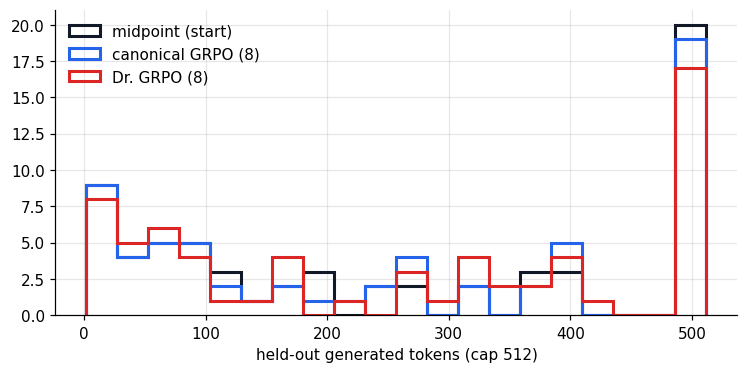

In [6]:
EV = {"midpoint (start)": load("task3_grpo/grpo_eval_midpoint.json"), "canonical GRPO (8)": load("task3_grpo/grpo_eval_fork_norm_grpo.json"),
      "Dr. GRPO (8)": load("task3_grpo/grpo_eval_fork_norm_dr_grpo.json"), "standard GRPO (20)": load("task3_grpo/grpo_eval_standard.json")}
display(pd.DataFrame({k: {"RM": e["mean_reward"], "RM s.e.m.": e["sem_reward"], "KL token": e["kl_token_mean"], "entropy": e["entropy_exact"],
                          "length mean": e["length_tokens"]["mean"], "length std": e["length_tokens"]["std"], "length median": e["length_tokens"]["median"],
                          "hit 512 cap": e["hit_max_tokens_rate"]} for k, e in EV.items()}).T.round(4))
fig, ax = plt.subplots(figsize=(8, 3.6))
for (k, e), c in zip(list(EV.items())[:3], ["#111827", "#2563EB", "#DC2626"]):
    ax.hist([g["response_length_tokens"] for g in e["generations"]], bins=20, histtype="step", lw=2, color=c, label=k)
ax.set_xlabel("held-out generated tokens (cap 512)"); ax.legend(); plt.show()

## 5. Qualitative: the completion with the largest gradient contribution in each fork

In [7]:
for n, r in RC.items():
    t = r[~r.masked].sort_values("grad_norm").iloc[-1]
    side_by_side(f"{n}: largest ‖g_k‖ (update {t["update"]})", t.prompt, {"completion": t.completion},
                 meta={"completion": f"length {t.length} · reward {t.reward:+.2f} · A {t.advantage:+.2f} · ‖g‖ {t.grad_norm:.3f}"}, limit=700)

completionlength 41 · reward +1.34 · A -1.17 · ‖g‖ 0.912The filter cartridge for separating flammable liquids with high amounts of solid particles has an output in which entrained mist droplets generated from woven curtains with filtering function are formed from heated air entering the chamber.


"completionlength 385 · reward +3.03 · A +1.65 · ‖g‖ 0.105Mycobacterium tuberculosis (MTB) is a type of bacteria that causes tuberculosis (TB). It can be found in the airways of infected people, making it easy for the bacteria to spread from one person to another through coughing or sneezing.Tuberculosis primarily affects the lungs but can also affect other parts of the body such as the bones, joints, and central nervous system. The disease is often fatal if not treated properly.The difficulty in treating TB lies in its ability to survive in harsh environments and evade the immune system's defenses. MTB has developed several strategies to avoid detection by the immune system:1. It forms protective capsules around itself, which prevent antibodies …"


## 6. Facts for RQ2

In [8]:
for k in ["grpo", "dr_grpo"]:
    lc, e = N[k]["length_conditioned"], N[k]["eval"]
    print(f"{N[k]['label']}: ρ_s(T, ‖g‖/|A|) {lc['spearman_length_vs_gradnorm_per_unit_adv']:+.3f}; gradient share shortest/longest third "
          f"{lc['grad_mass_share_shortest_third']:.3f}/{lc['grad_mass_share_longest_third']:.3f}; held-out length {e['length_tokens']['mean']:.1f}, RM {e['mean_reward']:.3f}")

canonical GRPO (1/T_k): ρ_s(T, ‖g‖/|A|) -0.877; gradient share shortest/longest third 0.731/0.091; held-out length 262.3, RM 1.442
Dr. GRPO (1/L_max): ρ_s(T, ‖g‖/|A|) +0.575; gradient share shortest/longest third 0.307/0.435; held-out length 260.8, RM 1.436
